In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
from datetime import datetime

169 338
44 21.00887573964497


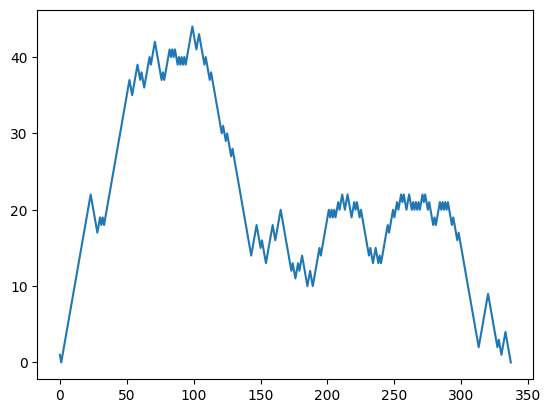

In [23]:
class Job:
    def __init__(self, jid, ts, te):
        self.jid, self.ts, self.te = jid, ts, te

fn = "./cluster_job.log"
with open(fn, 'r') as f:
    content = json.load(f)

jobs = []
events = []
start, end, step = 0, 10000, 10
for item in content[start:end:step]:
    jid = item['jobid']
    if len(item['attempts']) == 0 or item['attempts'][0]['start_time'] == 'None' or item['attempts'][0]['end_time'] == 'None':
        continue
    t_start = datetime.strptime(item['attempts'][0]['start_time'], "%Y-%m-%d %H:%M:%S")
    t_end = datetime.strptime(item['attempts'][0]['end_time'], "%Y-%m-%d %H:%M:%S")
    duration = (t_end - t_start).total_seconds()
    if duration >= 3600:
        jobs.append(Job(jid, t_start, t_end))
        events.append((t_start, 1, jid))
        events.append((t_end, -1, jid))

print(len(jobs), len(events))
running_jobs = 0
max_running_jobs = 0
running_job_sizes = []
events.sort()
with open(f"trace/philly_{start}_{end}_{step}.trace", 'w') as of:
    for (t, delta_n, jid) in events:
        of.write(f"{jid}, {t}, {delta_n}\n")
for (t, delta_n, jid) in events:
    running_jobs += delta_n
    max_running_jobs = max(max_running_jobs, running_jobs)
    running_job_sizes.append(running_jobs)
    # print(f"{t=}, {running_jobs=}")
plt.plot(running_job_sizes)
print(max_running_jobs, sum(running_job_sizes) / len(running_job_sizes))


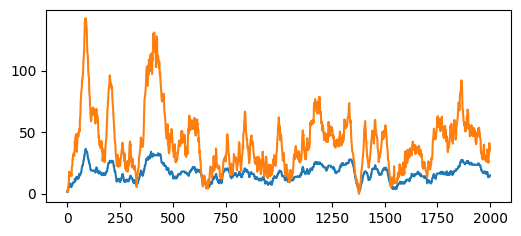

In [20]:
import datetime

def parse_line(line):
    mix_type, line = line.split("--")
    results = {}
    for method_line in line.split("||"):
        method, *items = method_line.split("|")
        total_cost = float(items[0])
        time_costs = eval(items[1])
        time_invalid_jobs = eval(items[2])
        results[method] = (total_cost, time_costs, time_invalid_jobs)
    return mix_type, results

with open("run_results.txt", 'r') as f:
    content = f.read().split("\n")

for line in content:
    if len(line) <= 1:
        continue
    mix_type, results = parse_line(line)
    plt.figure(figsize=(6, 2.5))
    plt.subplot(111)
    all_plotted = False
    for method in results:
        total_cost, time_costs, time_invalid_jobs = results[method]
        if len(time_costs) == 0:
            continue
        xs, invs, alls, costs = [], [], [], []
        calc_num_invalid_jobs = lambda group_invalid_jobs: sum(len(group_invalid_jobs[grp_id]) for grp_id in group_invalid_jobs)
        t0 = time_invalid_jobs[0][0]
        for (last_t, t, last_invalid, last_num_all) in time_invalid_jobs:
            xs.append((last_t - t0).total_seconds() / 3600 / 24)
            invs.append(calc_num_invalid_jobs(last_invalid))
            alls.append(last_num_all)
        for (last_t, t, cost_t) in time_costs:
            costs.append(cost_t)
        plt.plot(np.arange(len(xs)), costs)
        if not all_plotted:
            # plt.plot(np.arange(len(xs)), alls)
            all_plotted = True
